In [1]:
import seaborn as sns
import numpy as np
import sctop as top
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

Possible directions

What's the minimum amount of information we need to include in our model to capture the correct changes in proportion as a result of change in signaling?

Do we need to have some kind of threshold response, to measure "none, low, high" levels of signaling?

Do we need combinatorial signaling?

Can we find some structure in the matrices (vs. purely random matrices)? Some latent space of signaling?

# Data

[A map of signaling responses in the human airway epithelium](https://www.sciencedirect.com/science/article/pii/S2405471224000590)

Control + 17 conditions [GSE246368](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE246368)

"Human bronchial epithelial cells were cultured at air-liquid interface (ALI) without treatment to drive differentiation into a pseudo- stratified epithelium that recapitulates the physiological cell types of the airway. The differentiated luminal cells were then stripped through calcium depletion, leaving the remaining basal cells to regenerate the tissue. This was done in the presence of a signaling agonist added to each well at a dosage 10- to 100-fold greater than the IC50. One condition was kept unperturbed for control."


Control + OSM + Ifng [GSE246441](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE246441)

In [2]:
osm_ifng = sc.read_h5ad('/Users/maria/github/phenotype-signaling/GSE246441_all_10x_data.h5ad')
many_conditions = sc.read_h5ad('/Users/maria/github/phenotype-signaling/GSE246368_all_data.h5ad')

In [3]:
cellchatdb = pd.read_csv('/Users/maria/github/phenotype-signaling/CellChatDB.human.csv', index_col=0)

In [4]:
cellchatdb.head()

,interaction.interaction_name,interaction.pathway_name,interaction.ligand,interaction.receptor,interaction.agonist,interaction.antagonist,interaction.co_A_receptor,interaction.co_I_receptor,interaction.evidence,interaction.annotation,interaction.interaction_name_2
TGFB1_TGFBR1_TGFBR2,TGFB1_TGFBR1_TGFBR2,TGFb,TGFB1,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,KEGG: hsa04350,Secreted Signaling,TGFB1 - (TGFBR1+TGFBR2)
TGFB2_TGFBR1_TGFBR2,TGFB2_TGFBR1_TGFBR2,TGFb,TGFB2,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,KEGG: hsa04350,Secreted Signaling,TGFB2 - (TGFBR1+TGFBR2)
TGFB3_TGFBR1_TGFBR2,TGFB3_TGFBR1_TGFBR2,TGFb,TGFB3,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,KEGG: hsa04350,Secreted Signaling,TGFB3 - (TGFBR1+TGFBR2)
TGFB1_ACVR1B_TGFBR2,TGFB1_ACVR1B_TGFBR2,TGFb,TGFB1,ACVR1B_TGFbR2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,PMID: 27449815,Secreted Signaling,TGFB1 - (ACVR1B+TGFBR2)
TGFB1_ACVR1C_TGFBR2,TGFB1_ACVR1C_TGFBR2,TGFb,TGFB1,ACVR1C_TGFbR2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,PMID: 27449815,Secreted Signaling,TGFB1 - (ACVR1C+TGFBR2)


In [5]:
many_conditions.obs[['condition']].value_counts()

condition
None         7564
IGF1         6498
TGFB1        6265
TNFA         5863
ActA         4819
IFNA         4774
IL17A        4485
FGF10        4430
Adipo        4260
EGF          4127
BMP4         3891
IL13         3590
Leptin       3397
HGF          3396
OSM          2669
CHIR         2643
FGF2         2623
IFNG         2274
Name: count, dtype: int64

In [6]:
many_conditions.obs[many_conditions.obs['condition'] == 'None']['cell_states'].value_counts()

cell_states
Basal            2638
Club             2472
Multiciliated    2297
Ionocyte           67
Goblet             40
Tuft               40
PNEC               10
Indeterminate       0
Name: count, dtype: int64

# Phenotype-signal model with consumer-resource-like behavior

$$
\frac{dN_\mu}{dt} = \sum_{\nu \alpha} T_{\mu \nu} c_{\nu \alpha} L_{\alpha} N_{\nu} - \sum_{\gamma \beta} T_{\gamma \mu} c_{\mu \beta} L_{\beta} N_{\mu} - m_{\mu} N_{\mu}
$$

$$
\frac{dL_{\alpha}}{dt} = k_{\alpha} - r L_{\alpha} - \sum_{\mu \nu} T_{\mu \nu} c_{\nu \alpha} N_{\mu} L_{\alpha} + \sum_{\gamma} P_{\beta \gamma } N_{\gamma} 
$$

Variables:
- $N_{\mu}$: number of cells of cell type $\mu$
- $L_{\alpha}$: number of ligands of type $\alpha$
- $T_{\mu \nu}$: probability of transitioning from cell type $\nu$ to cell type $\mu$
- $c_{\nu \alpha}$: responsivity of cell type $\nu$ to ligand $\alpha$
- $m_{\mu}$: "mortality" of cell type $\mu$ (cell turnover rate for a given cell type?)
- $k_{\alpha}$: external supply of ligand $\alpha$
- $r$: dissociation rate of ligands
- $P_{\gamma \beta}$: production of ligand $\beta$ by cell type $\gamma$

Parameters from gene expression:
- Use Hopfield-like proximity-based likelihood for cell-type transition matrix: $T_{\mu \nu} = \frac{e^{- \beta ||\xi_{\mu} - \xi_{\nu}||^2}}{\sum_{\gamma} e^{- \beta ||\xi_{\mu} - \xi_{\gamma}||^2}}$ where $\xi_{\mu}$ is the gene expression profile for cell type $\mu$
- Combine receptor availibility with information about ligand-binding to find the phenotype-specific ligand responsivity: $c_{\nu \alpha} = \sum_i^{N_r} \xi_{\nu i} B_{i \alpha}$ where $i$ is summing over the receptors and $B$ is a binary matrix indicating whether ligand $\alpha$ binds to receptor $i$ (can use CellChat to sum over interacting ligand-receptor pairs)
- Use gene expression of ligand $\beta$ in cell type $\gamma$ for $P_{\gamma \beta}$

Free parameters: $m_{\mu}$, $d$

# 1. Processing the data

- Find average gene expression profiles for basal, club, ciliated, and goblet with sctop.process(..., average=True)
- Extract parameters for the model using CellChatDB and the average gene expression profiles

In [7]:
phenotypes = ['Basal', 'Club', 'Multiciliated'] # take the 3 most abundant types to start
control_data = many_conditions[many_conditions.obs['condition'] == 'None'] # take control condition (no signals added)
df_list = []

for ptype in phenotypes: 
    type_mask = control_data.obs['cell_states'] == ptype
    indices = control_data.obs[type_mask].index
    processed_counts = top.process(control_data[indices].X.T.toarray(), average=True)
    processed_counts.index = control_data.var.index
    processed_counts.columns = [ptype]
    df_list += [processed_counts]

control_xi = pd.concat(df_list, axis=1)

In [8]:
[gene for gene in control_xi.index if 'RAR' in gene]

['NRARP',
 'RARA',
 'RARA-AS1',
 'RARB',
 'RARG',
 'RARRES1',
 'RARRES2',
 'RARRES3',
 'RARS',
 'RARS2',
 'SRARP']

In [247]:
control_xi

,Basal,Club,Multiciliated
5S_rRNA,-0.000369,-0.004497,0.000491
5_8S_rRNA,-0.004481,-0.004497,-0.004198
7SK,-0.004481,0.000601,0.000491
A1BG,0.002136,0.002021,0.002239
A1BG-AS1,0.000697,-0.000422,0.002682
...,...,...,...
snoZ278,-0.004481,-0.004497,-0.004198
snoZ40,-0.004481,-0.004497,-0.004198
snoZ6,-0.004481,-0.004497,-0.004198
snosnR66,-0.004481,-0.004497,0.001690


In [9]:
genes = control_xi.index

ligands = np.intersect1d(genes, cellchatdb['interaction.ligand'])
receptors = np.intersect1d(genes, cellchatdb['interaction.receptor'])

print(f'Data includes {len(ligands)} ligands and {len(receptors)} receptors')
print(f'(Out of {len(cellchatdb['interaction.ligand'].unique())} possible ligands and {len(cellchatdb['interaction.receptor'].unique())} possible receptors in the CellChat database)')

Data includes 529 ligands and 358 receptors
(Out of 546 possible ligands and 507 possible receptors in the CellChat database)


In [10]:
# Binary receptor x ligand interaction matrix from CellChatDB
lr_pairs = (
    cellchatdb[['interaction.receptor', 'interaction.ligand']]
)

receptor_ligand_matrix = pd.crosstab(
    lr_pairs['interaction.receptor'],
    lr_pairs['interaction.ligand']
).astype(int)

receptor_ligand_matrix = receptor_ligand_matrix.loc[receptors, ligands]

In [11]:
# Use a version of the gene expression profiles where negative (lowly-expressed) genes
# are converted to 0's (to avoid adding negative terms to the dynamics)
# i.e.: lowly-expressed receptors/ligands have no effect
control_xi_nonneg = control_xi.clip(lower=0)

ligand_responsivity = control_xi_nonneg.loc[receptors].T.dot(receptor_ligand_matrix)
ligand_production = control_xi_nonneg.loc[ligands]

In [12]:
notch_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == 'NOTCH']['interaction.ligand'].unique()
notch_receptors = cellchatdb[cellchatdb['interaction.pathway_name'] == 'NOTCH']['interaction.receptor'].unique()

In [14]:
ligand_responsivity[notch_ligands]

interaction.ligand,DLK1,DLL1,DLL3,DLL4,JAG1,JAG2
Basal,0.032559,0.032559,0.032559,0.032559,0.032559,0.032559
Club,0.029771,0.029771,0.029771,0.029771,0.029771,0.029771
Multiciliated,0.020117,0.020117,0.020117,0.020117,0.020117,0.020117


In [16]:
ligand_production.loc[notch_ligands]

,Basal,Club,Multiciliated
DLK1,0.001216,0.001098,0.000000
DLL1,0.006044,0.003280,0.004509
DLL3,0.000000,0.000601,0.000000
DLL4,0.000000,0.001098,0.000000
JAG1,0.010250,0.006775,0.004843
JAG2,0.010270,0.006584,0.009973


In [252]:
vcam_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == 'NOTCH']['interaction.ligand'].unique()

In [254]:
path_resp

interaction.ligand,VSIR
Basal,0.002646
Club,0.002450
Multiciliated,0.002156


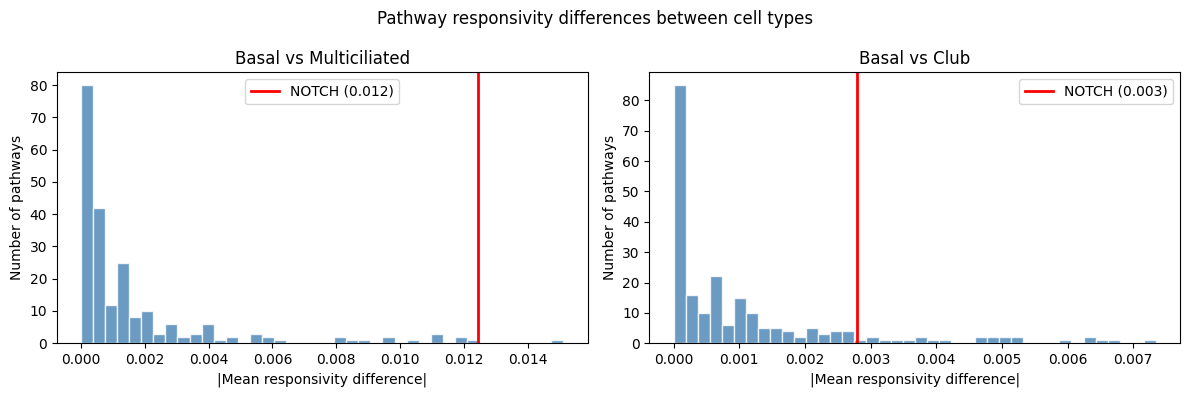

In [255]:
# For each pathway, compute responsivity difference between cell type pairs
pathway_names = cellchatdb['interaction.pathway_name'].unique()

basal_vs_ciliated = {}
basal_vs_club = {}

for pathway in pathway_names:
    path_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == pathway]['interaction.ligand'].unique()
    path_ligands_avail = np.intersect1d(path_ligands, ligands)
    if len(path_ligands_avail) == 0:
        continue
    # Mean responsivity per cell type for this pathway's ligands
    path_resp = ligand_responsivity[path_ligands_avail]  # (n_phenotypes, n_path_ligands)
    mean_resp = path_resp.mean(axis=1)  # mean across ligands
    basal_vs_ciliated[pathway] = abs(mean_resp['Basal'] - mean_resp['Multiciliated'])
    basal_vs_club[pathway] = abs(mean_resp['Basal'] - mean_resp['Club'])

basal_vs_ciliated = pd.Series(basal_vs_ciliated).sort_values()
basal_vs_club = pd.Series(basal_vs_club).sort_values()

notch_bvc = basal_vs_ciliated.get('NOTCH', None)
notch_bvclub = basal_vs_club.get('NOTCH', None)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(basal_vs_ciliated.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
if notch_bvc is not None:
    axes[0].axvline(notch_bvc, color='red', linewidth=2, label=f'NOTCH ({notch_bvc:.3f})')
    axes[0].legend()
axes[0].set_xlabel('|Mean responsivity difference|')
axes[0].set_ylabel('Number of pathways')
axes[0].set_title('Basal vs Multiciliated')

axes[1].hist(basal_vs_club.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
if notch_bvclub is not None:
    axes[1].axvline(notch_bvclub, color='red', linewidth=2, label=f'NOTCH ({notch_bvclub:.3f})')
    axes[1].legend()
axes[1].set_xlabel('|Mean responsivity difference|')
axes[1].set_ylabel('Number of pathways')
axes[1].set_title('Basal vs Club')

plt.suptitle('Pathway responsivity differences between cell types')
plt.tight_layout()
plt.show()


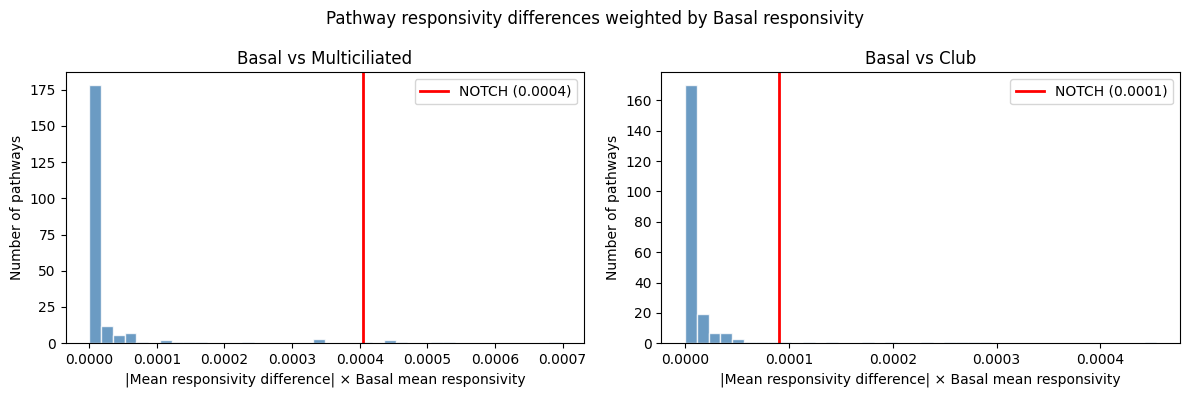

In [256]:
# Pathway responsivity differences weighted by Basal responsivity

basal_weighted_vs_ciliated = {}
basal_weighted_vs_club = {}

for pathway in pathway_names:
    path_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == pathway]['interaction.ligand'].unique()
    path_ligands_avail = np.intersect1d(path_ligands, ligands)
    if len(path_ligands_avail) == 0:
        continue

    path_resp = ligand_responsivity[path_ligands_avail]
    mean_resp = path_resp.mean(axis=1)

    basal_resp = mean_resp['Basal']
    basal_weighted_vs_ciliated[pathway] = abs(mean_resp['Basal'] - mean_resp['Multiciliated']) * basal_resp
    basal_weighted_vs_club[pathway] = abs(mean_resp['Basal'] - mean_resp['Club']) * basal_resp

basal_weighted_vs_ciliated = pd.Series(basal_weighted_vs_ciliated).sort_values()
basal_weighted_vs_club = pd.Series(basal_weighted_vs_club).sort_values()

notch_bvc_weighted = basal_weighted_vs_ciliated.get('NOTCH', None)
notch_bvclub_weighted = basal_weighted_vs_club.get('NOTCH', None)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(basal_weighted_vs_ciliated.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
if notch_bvc_weighted is not None:
    axes[0].axvline(notch_bvc_weighted, color='red', linewidth=2, label=f'NOTCH ({notch_bvc_weighted:.4f})')
    axes[0].legend()
axes[0].set_xlabel('|Mean responsivity difference| × Basal mean responsivity')
axes[0].set_ylabel('Number of pathways')
axes[0].set_title('Basal vs Multiciliated')

axes[1].hist(basal_weighted_vs_club.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
if notch_bvclub_weighted is not None:
    axes[1].axvline(notch_bvclub_weighted, color='red', linewidth=2, label=f'NOTCH ({notch_bvclub_weighted:.4f})')
    axes[1].legend()
axes[1].set_xlabel('|Mean responsivity difference| × Basal mean responsivity')
axes[1].set_ylabel('Number of pathways')
axes[1].set_title('Basal vs Club')

plt.suptitle('Pathway responsivity differences weighted by Basal responsivity')
plt.tight_layout()
plt.show()

In [257]:
# Pathways above threshold in both weighted histograms (Basal vs Multiciliated and Basal vs Club)
threshold = 5e-5

pathways_both = (
    pd.DataFrame({
        'basal_weighted_vs_ciliated': basal_weighted_vs_ciliated,
        'basal_weighted_vs_club': basal_weighted_vs_club
    })
    .dropna()
)

pathways_both = pathways_both[
    (pathways_both['basal_weighted_vs_ciliated'] > threshold) |
    (pathways_both['basal_weighted_vs_club'] > threshold)
].sort_values(by=['basal_weighted_vs_ciliated', 'basal_weighted_vs_club'], ascending=False)

print(f'Pathways > {threshold} in either histogram: {len(pathways_both)}')
print(pathways_both.index.tolist())
print(pathways_both)

Pathways > 5e-05 in either histogram: 24
['MK', 'PTN', 'EPHB', 'FN1', 'COLLAGEN', 'ncWNT', 'NOTCH', 'EPHA', 'SELE', 'LAMININ', 'THBS', 'GALECTIN', 'CD96', 'FGF', 'SPP1', 'MIF', 'TENASCIN', 'GH', 'CD99', 'DESMOSOME', 'GAS', 'SEMA5', 'APP', 'CD46']
           basal_weighted_vs_ciliated  basal_weighted_vs_club
MK                           0.000697                0.000454
PTN                          0.000538                0.000287
EPHB                         0.000520                0.000231
FN1                          0.000454                0.000261
COLLAGEN                     0.000448                0.000280
ncWNT                        0.000448                0.000261
NOTCH                        0.000405                0.000091
EPHA                         0.000348                0.000203
SELE                         0.000346                0.000174
LAMININ                      0.000334                0.000148
THBS                         0.000236                0.000119
GALECTIN 

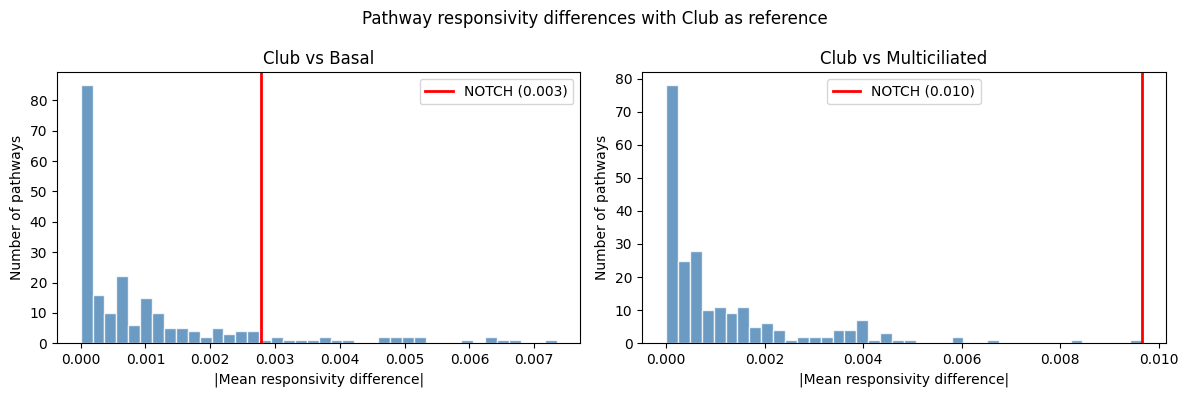

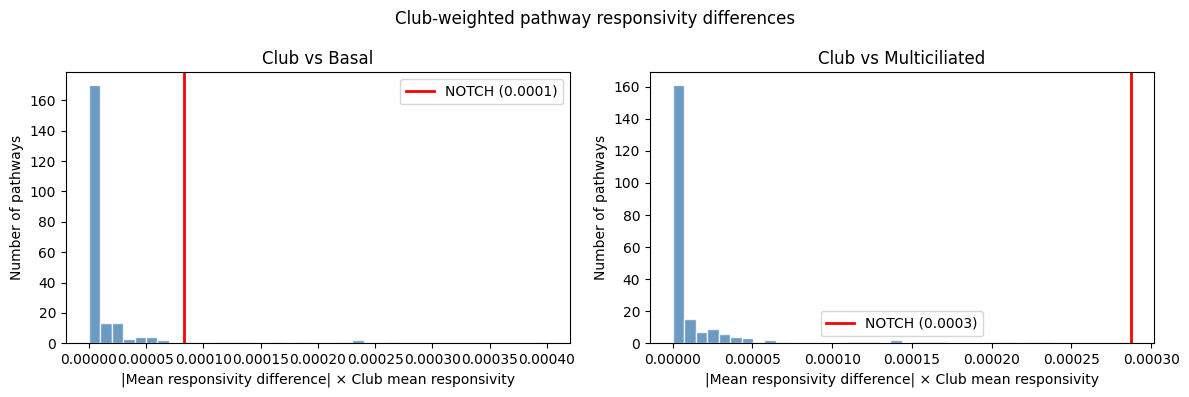

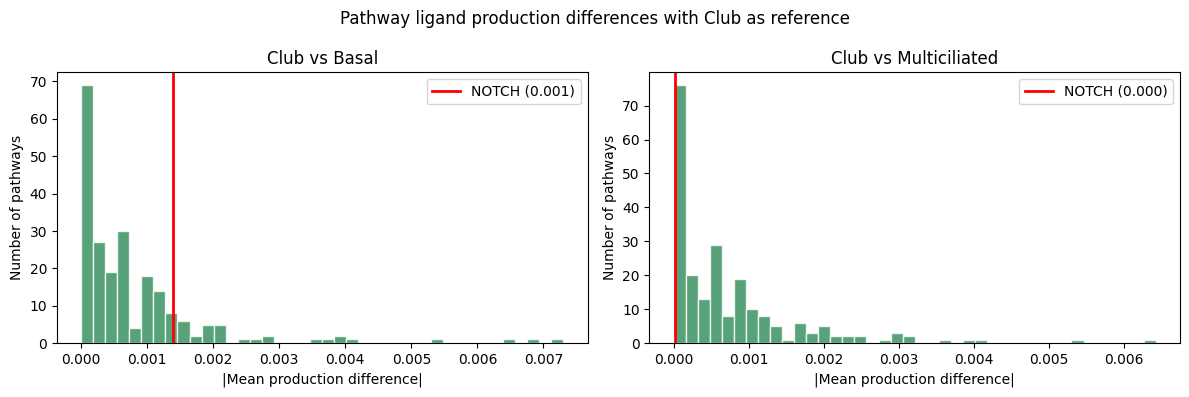

In [258]:
# Club as base phenotype: pathway responsivity differences
club_vs_basal = {}
club_vs_ciliated = {}

for pathway in pathway_names:
    path_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == pathway]['interaction.ligand'].unique()
    path_ligands_avail = np.intersect1d(path_ligands, ligands)
    if len(path_ligands_avail) == 0:
        continue

    path_resp = ligand_responsivity[path_ligands_avail]
    mean_resp = path_resp.mean(axis=1)

    club_vs_basal[pathway] = abs(mean_resp['Club'] - mean_resp['Basal'])
    club_vs_ciliated[pathway] = abs(mean_resp['Club'] - mean_resp['Multiciliated'])

club_vs_basal = pd.Series(club_vs_basal).sort_values()
club_vs_ciliated = pd.Series(club_vs_ciliated).sort_values()

notch_cvb = club_vs_basal.get('NOTCH', None)
notch_cvm = club_vs_ciliated.get('NOTCH', None)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(club_vs_basal.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
if notch_cvb is not None:
    axes[0].axvline(notch_cvb, color='red', linewidth=2, label=f'NOTCH ({notch_cvb:.3f})')
    axes[0].legend()
axes[0].set_xlabel('|Mean responsivity difference|')
axes[0].set_ylabel('Number of pathways')
axes[0].set_title('Club vs Basal')

axes[1].hist(club_vs_ciliated.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
if notch_cvm is not None:
    axes[1].axvline(notch_cvm, color='red', linewidth=2, label=f'NOTCH ({notch_cvm:.3f})')
    axes[1].legend()
axes[1].set_xlabel('|Mean responsivity difference|')
axes[1].set_ylabel('Number of pathways')
axes[1].set_title('Club vs Multiciliated')

plt.suptitle('Pathway responsivity differences with Club as reference')
plt.tight_layout()
plt.show()


# Club-weighted responsivity differences
club_weighted_vs_basal = {}
club_weighted_vs_ciliated = {}

for pathway in pathway_names:
    path_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == pathway]['interaction.ligand'].unique()
    path_ligands_avail = np.intersect1d(path_ligands, ligands)
    if len(path_ligands_avail) == 0:
        continue

    path_resp = ligand_responsivity[path_ligands_avail]
    mean_resp = path_resp.mean(axis=1)

    club_resp = mean_resp['Club']
    club_weighted_vs_basal[pathway] = abs(mean_resp['Club'] - mean_resp['Basal']) * club_resp
    club_weighted_vs_ciliated[pathway] = abs(mean_resp['Club'] - mean_resp['Multiciliated']) * club_resp

club_weighted_vs_basal = pd.Series(club_weighted_vs_basal).sort_values()
club_weighted_vs_ciliated = pd.Series(club_weighted_vs_ciliated).sort_values()

notch_cvb_w = club_weighted_vs_basal.get('NOTCH', None)
notch_cvm_w = club_weighted_vs_ciliated.get('NOTCH', None)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(club_weighted_vs_basal.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
if notch_cvb_w is not None:
    axes[0].axvline(notch_cvb_w, color='red', linewidth=2, label=f'NOTCH ({notch_cvb_w:.4f})')
    axes[0].legend()
axes[0].set_xlabel('|Mean responsivity difference| × Club mean responsivity')
axes[0].set_ylabel('Number of pathways')
axes[0].set_title('Club vs Basal')

axes[1].hist(club_weighted_vs_ciliated.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
if notch_cvm_w is not None:
    axes[1].axvline(notch_cvm_w, color='red', linewidth=2, label=f'NOTCH ({notch_cvm_w:.4f})')
    axes[1].legend()
axes[1].set_xlabel('|Mean responsivity difference| × Club mean responsivity')
axes[1].set_ylabel('Number of pathways')
axes[1].set_title('Club vs Multiciliated')

plt.suptitle('Club-weighted pathway responsivity differences')
plt.tight_layout()
plt.show()


# Club as base phenotype: pathway ligand production differences
club_vs_basal_prod = {}
club_vs_ciliated_prod = {}

for pathway in pathway_names:
    path_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == pathway]['interaction.ligand'].unique()
    path_ligands_avail = np.intersect1d(path_ligands, ligand_production.index.values)
    if len(path_ligands_avail) == 0:
        continue

    path_prod = ligand_production.loc[path_ligands_avail]
    mean_prod = path_prod.mean(axis=0)

    club_vs_basal_prod[pathway] = abs(mean_prod['Club'] - mean_prod['Basal'])
    club_vs_ciliated_prod[pathway] = abs(mean_prod['Club'] - mean_prod['Multiciliated'])

club_vs_basal_prod = pd.Series(club_vs_basal_prod).sort_values()
club_vs_ciliated_prod = pd.Series(club_vs_ciliated_prod).sort_values()

notch_cvb_prod = club_vs_basal_prod.get('NOTCH', None)
notch_cvm_prod = club_vs_ciliated_prod.get('NOTCH', None)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(club_vs_basal_prod.values, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
if notch_cvb_prod is not None:
    axes[0].axvline(notch_cvb_prod, color='red', linewidth=2, label=f'NOTCH ({notch_cvb_prod:.3f})')
    axes[0].legend()
axes[0].set_xlabel('|Mean production difference|')
axes[0].set_ylabel('Number of pathways')
axes[0].set_title('Club vs Basal')

axes[1].hist(club_vs_ciliated_prod.values, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
if notch_cvm_prod is not None:
    axes[1].axvline(notch_cvm_prod, color='red', linewidth=2, label=f'NOTCH ({notch_cvm_prod:.3f})')
    axes[1].legend()
axes[1].set_xlabel('|Mean production difference|')
axes[1].set_ylabel('Number of pathways')
axes[1].set_title('Club vs Multiciliated')

plt.suptitle('Pathway ligand production differences with Club as reference')
plt.tight_layout()
plt.show()

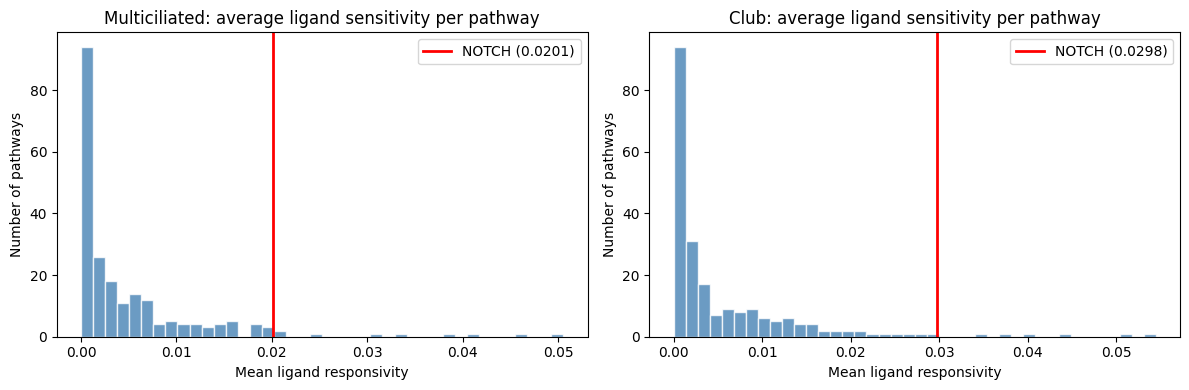

In [259]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pair_labels = ['Multiciliated', 'Club']
for ax, ptype in zip(axes, pair_labels):
    pathway_mean_resp = {}
    for pathway in pathway_names:
        path_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == pathway]['interaction.ligand'].unique()
        path_ligands_avail = np.intersect1d(path_ligands, ligands)
        if len(path_ligands_avail) == 0:
            continue
        pathway_mean_resp[pathway] = ligand_responsivity.loc[ptype, path_ligands_avail].mean()
    
    pathway_mean_resp = pd.Series(pathway_mean_resp)
    notch_val = pathway_mean_resp.get('NOTCH', None)
    
    ax.hist(pathway_mean_resp.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    if notch_val is not None:
        ax.axvline(notch_val, color='red', linewidth=2, label=f'NOTCH ({notch_val:.4f})')
        ax.legend()
    ax.set_xlabel('Mean ligand responsivity')
    ax.set_ylabel('Number of pathways')
    ax.set_title(f'{ptype}: average ligand sensitivity per pathway')

plt.tight_layout()
plt.show()

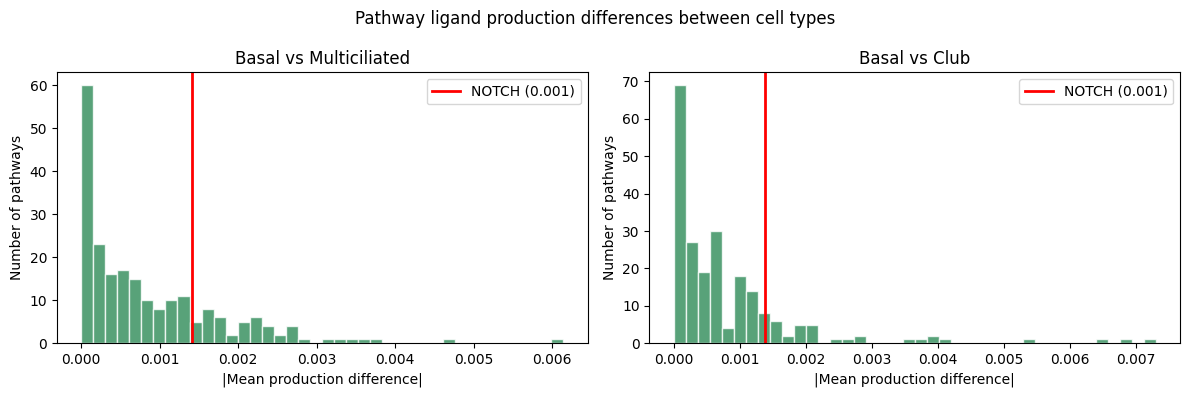

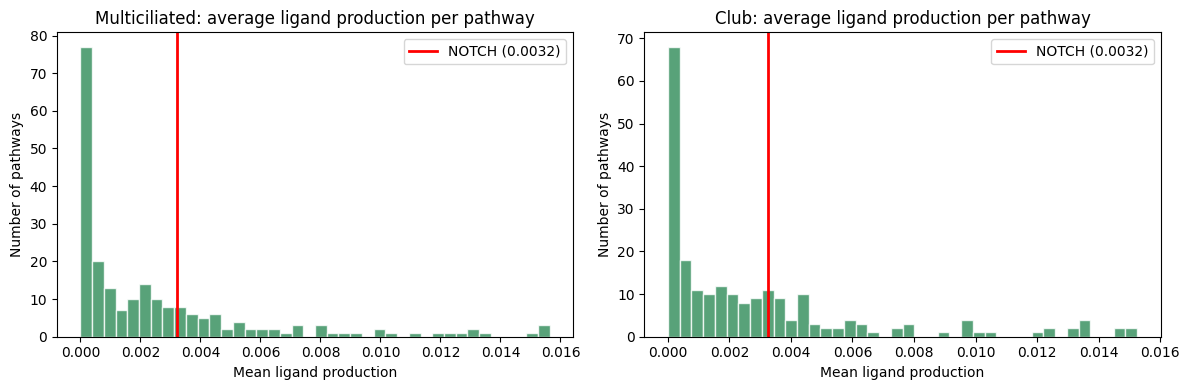

In [260]:
# Pathway-level ligand production differences (analogous to responsivity analysis)

basal_vs_ciliated_prod = {}
basal_vs_club_prod = {}

for pathway in pathway_names:
    path_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == pathway]['interaction.ligand'].unique()
    path_ligands_avail = np.intersect1d(path_ligands, ligand_production.index.values)
    if len(path_ligands_avail) == 0:
        continue

    # Mean ligand production per phenotype for this pathway
    path_prod = ligand_production.loc[path_ligands_avail]  # (n_path_ligands, n_phenotypes)
    mean_prod = path_prod.mean(axis=0)  # mean across ligands -> per phenotype

    basal_vs_ciliated_prod[pathway] = abs(mean_prod['Basal'] - mean_prod['Multiciliated'])
    basal_vs_club_prod[pathway] = abs(mean_prod['Basal'] - mean_prod['Club'])

basal_vs_ciliated_prod = pd.Series(basal_vs_ciliated_prod).sort_values()
basal_vs_club_prod = pd.Series(basal_vs_club_prod).sort_values()

# NOTCH reference values
notch_ligands_avail = np.intersect1d(notch_ligands, ligand_production.index.values)
if len(notch_ligands_avail) > 0:
    notch_mean_prod = ligand_production.loc[notch_ligands_avail].mean(axis=0)
    notch_bvc_prod = abs(notch_mean_prod['Basal'] - notch_mean_prod['Multiciliated'])
    notch_bvclub_prod = abs(notch_mean_prod['Basal'] - notch_mean_prod['Club'])
else:
    notch_bvc_prod = None
    notch_bvclub_prod = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(basal_vs_ciliated_prod.values, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
if notch_bvc_prod is not None:
    axes[0].axvline(notch_bvc_prod, color='red', linewidth=2, label=f'NOTCH ({notch_bvc_prod:.3f})')
    axes[0].legend()
axes[0].set_xlabel('|Mean production difference|')
axes[0].set_ylabel('Number of pathways')
axes[0].set_title('Basal vs Multiciliated')

axes[1].hist(basal_vs_club_prod.values, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
if notch_bvclub_prod is not None:
    axes[1].axvline(notch_bvclub_prod, color='red', linewidth=2, label=f'NOTCH ({notch_bvclub_prod:.3f})')
    axes[1].legend()
axes[1].set_xlabel('|Mean production difference|')
axes[1].set_ylabel('Number of pathways')
axes[1].set_title('Basal vs Club')

plt.suptitle('Pathway ligand production differences between cell types')
plt.tight_layout()
plt.show()

# Distribution of pathway mean ligand production per phenotype (same style as above)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ptype in zip(axes, pair_labels):
    pathway_mean_prod = {}
    for pathway in pathway_names:
        path_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == pathway]['interaction.ligand'].unique()
        path_ligands_avail = np.intersect1d(path_ligands, ligand_production.index.values)
        if len(path_ligands_avail) == 0:
            continue
        pathway_mean_prod[pathway] = ligand_production.loc[path_ligands_avail, ptype].mean()

    pathway_mean_prod = pd.Series(pathway_mean_prod)
    notch_val_prod = pathway_mean_prod.get('NOTCH', None)

    ax.hist(pathway_mean_prod.values, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
    if notch_val_prod is not None:
        ax.axvline(notch_val_prod, color='red', linewidth=2, label=f'NOTCH ({notch_val_prod:.4f})')
        ax.legend()
    ax.set_xlabel('Mean ligand production')
    ax.set_ylabel('Number of pathways')
    ax.set_title(f'{ptype}: average ligand production per pathway')

plt.tight_layout()
plt.show()

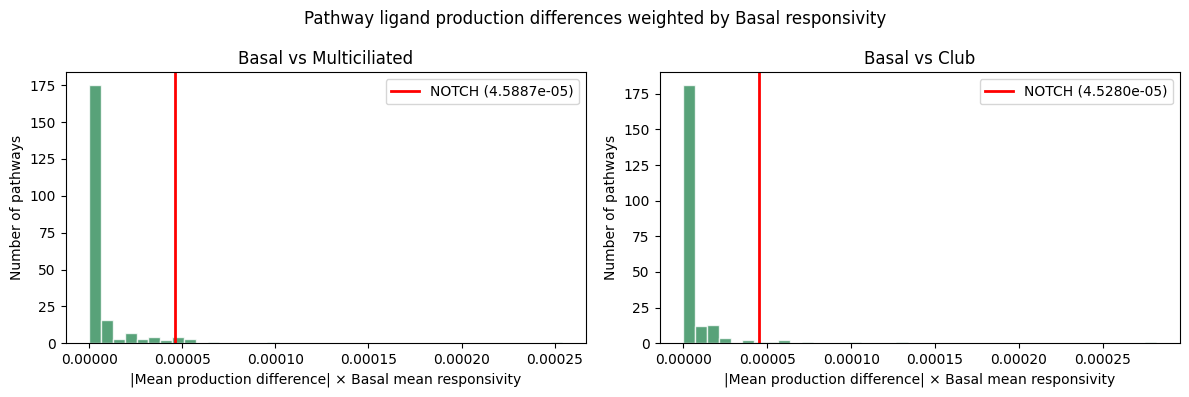

In [261]:
# Pathway-level ligand production differences weighted by Basal ligand responsivity

basal_prod_weighted_vs_ciliated = {}
basal_prod_weighted_vs_club = {}

for pathway in pathway_names:
    path_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == pathway]['interaction.ligand'].unique()
    path_ligands_avail = np.intersect1d(
        path_ligands,
        np.intersect1d(ligand_production.index.values, ligand_responsivity.columns.values)
    )
    if len(path_ligands_avail) == 0:
        continue

    path_prod = ligand_production.loc[path_ligands_avail]
    mean_prod = path_prod.mean(axis=0)

    basal_resp = ligand_responsivity.loc['Basal', path_ligands_avail].mean()

    basal_prod_weighted_vs_ciliated[pathway] = abs(mean_prod['Basal'] - mean_prod['Multiciliated']) * basal_resp
    basal_prod_weighted_vs_club[pathway] = abs(mean_prod['Basal'] - mean_prod['Club']) * basal_resp

basal_prod_weighted_vs_ciliated = pd.Series(basal_prod_weighted_vs_ciliated).sort_values()
basal_prod_weighted_vs_club = pd.Series(basal_prod_weighted_vs_club).sort_values()

notch_ligands_avail_weighted = np.intersect1d(
    notch_ligands,
    np.intersect1d(ligand_production.index.values, ligand_responsivity.columns.values)
)

if len(notch_ligands_avail_weighted) > 0:
    notch_mean_prod_weighted = ligand_production.loc[notch_ligands_avail_weighted].mean(axis=0)
    notch_basal_resp = ligand_responsivity.loc['Basal', notch_ligands_avail_weighted].mean()
    notch_bvc_prod_weighted = abs(notch_mean_prod_weighted['Basal'] - notch_mean_prod_weighted['Multiciliated']) * notch_basal_resp
    notch_bvclub_prod_weighted = abs(notch_mean_prod_weighted['Basal'] - notch_mean_prod_weighted['Club']) * notch_basal_resp
else:
    notch_bvc_prod_weighted = None
    notch_bvclub_prod_weighted = None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(basal_prod_weighted_vs_ciliated.values, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
if notch_bvc_prod_weighted is not None:
    axes[0].axvline(notch_bvc_prod_weighted, color='red', linewidth=2, label=f'NOTCH ({notch_bvc_prod_weighted:.4e})')
    axes[0].legend()
axes[0].set_xlabel('|Mean production difference| × Basal mean responsivity')
axes[0].set_ylabel('Number of pathways')
axes[0].set_title('Basal vs Multiciliated')

axes[1].hist(basal_prod_weighted_vs_club.values, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
if notch_bvclub_prod_weighted is not None:
    axes[1].axvline(notch_bvclub_prod_weighted, color='red', linewidth=2, label=f'NOTCH ({notch_bvclub_prod_weighted:.4e})')
    axes[1].legend()
axes[1].set_xlabel('|Mean production difference| × Basal mean responsivity')
axes[1].set_ylabel('Number of pathways')
axes[1].set_title('Basal vs Club')

plt.suptitle('Pathway ligand production differences weighted by Basal responsivity')
plt.tight_layout()
plt.show()

In [262]:
ligand_responsivity[notch_ligands]

interaction.ligand,DLK1,DLL1,DLL3,DLL4,JAG1,JAG2
Basal,0.032559,0.032559,0.032559,0.032559,0.032559,0.032559
Club,0.029771,0.029771,0.029771,0.029771,0.029771,0.029771
Multiciliated,0.020117,0.020117,0.020117,0.020117,0.020117,0.020117


In [263]:
control_xi.loc[notch_receptors]

,Basal,Club,Multiciliated
NOTCH1,0.010091,0.006125,0.004611
NOTCH2,0.008606,0.009713,0.005961
NOTCH3,0.010726,0.010934,0.006276
NOTCH4,0.003136,0.002998,0.003269


In [264]:
ligand_responsivity

interaction.ligand,ADCYAP1,ADGRE5,ADIPOQ,ADM,AGRN,AGT,ALCAM,AMH,ANGPT1,ANGPT2,...,WNT5B,WNT6,WNT7A,WNT7B,WNT8A,WNT8B,WNT9A,WNT9B,XCL1,XCL2
Basal,0.0,0.005754,0.019619,0.004267,0.009432,0.003170,0.002371,0.0,0.000000,0.000000,...,0.048147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000697,0.000697
Club,0.0,0.010863,0.019356,0.003683,0.009217,0.002602,0.001431,0.0,0.000601,0.000601,...,0.043360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000601,0.000601
Multiciliated,0.0,0.007829,0.018909,0.003629,0.008848,0.004206,0.001955,0.0,0.000491,0.000491,...,0.039999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


In [13]:
from scipy.special import softmax

beta = 5 # fairly low to allow for transitions

# Gene expression profiles: shape (n_genes, n_phenotypes)
xi = control_xi[phenotypes].values

# Squared Euclidean distances between phenotype profiles
# D[mu, nu] = ||xi_mu - xi_nu||^2
xi_T = xi.T  # (n_phenotypes, n_genes)
D = np.sum((xi_T[:, np.newaxis, :] - xi_T[np.newaxis, :, :])**2, axis=-1)

# T[mu, nu] = exp(-beta * D[mu, nu]) / sum_gamma exp(-beta * D[mu, gamma])
# softmax over columns (axis=1) for each row mu
cell_type_transitions = pd.DataFrame(
    softmax(-beta * D, axis=1),
    index=phenotypes,
    columns=phenotypes
)
cell_type_transitions


,Basal,Club,Multiciliated
Basal,0.555875,0.256935,0.187190
Club,0.250444,0.541831,0.207724
Multiciliated,0.195770,0.222876,0.581354


# 2. Simulations

In [31]:
from scipy.integrate import solve_ivp

# Parameters
m = 0.001  # mortality/turnover rate (equal for all phenotypes)
r = 0.01  # ligand dissociation rate

n_phenotypes = len(phenotypes)
n_ligands = len(ligands)

C = ligand_responsivity.values    # (n_phenotypes, n_ligands): c[nu, alpha]
T = cell_type_transitions.values  # (n_phenotypes, n_phenotypes): T[mu, nu]
P = ligand_production.values      # (n_ligands, n_phenotypes): P[alpha, gamma]
TC = T @ C                        # precompute (n_phenotypes, n_ligands)

rng = np.random.default_rng(seed=42)
k = rng.binomial(1, 0.1, size=n_ligands) # fixed random external supply rate per ligand

def dydt(t, y):
    N = y[:n_phenotypes]
    L = y[n_phenotypes:]

    CL = C @ L  # effective signal per phenotype, shape (n_phenotypes,)

    # dN_mu/dt = sum_{nu,alpha} T_{mu,nu} c_{nu,alpha} L_alpha N_nu
    #           - sum_{gamma,beta} T_{gamma,mu} c_{mu,beta} L_beta N_mu
    #           - m * N_mu
    gain_N = T @ (N * CL)
    loss_N = N * CL * T.sum(axis=0)
    dN = gain_N - loss_N - m * N

    # dL_alpha/dt = k_alpha - r L_alpha
    #              - L_alpha * sum_{mu,nu} T_{mu,nu} c_{nu,alpha} N_mu
    #              + sum_gamma P_{gamma,alpha} N_gamma
    consumption_L = L * (TC.T @ N)
    production_L = P @ N
    dL = k - r * L - consumption_L + production_L

    return np.concatenate([dN, dL])

# Initial conditions: only basal cells, no ligands
N0 = np.array([1, 0, 0])
L0 = np.zeros(n_ligands)
y0 = np.concatenate([N0, L0])

t_span = (0, 50)
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(dydt, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-6)
print(f'Integration {"succeeded" if sol.success else "failed"}: {sol.message}')


Integration succeeded: The solver successfully reached the end of the integration interval.


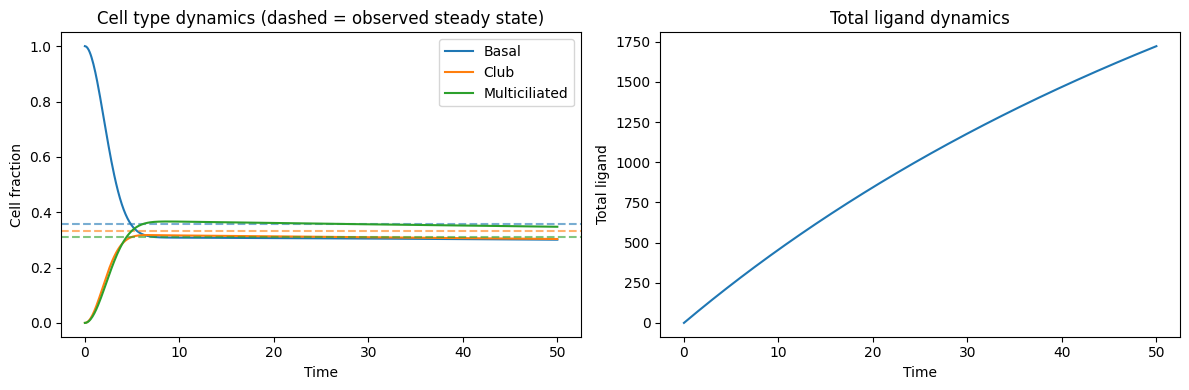

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Observed steady-state fractions from control data (normalized to phenotypes of interest)
observed_counts = control_data.obs['cell_states'].value_counts()
observed_counts = observed_counts[phenotypes]
observed_fractions = observed_counts / observed_counts.sum()

N_sol = sol.y[:n_phenotypes]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, ptype in enumerate(phenotypes):
    axes[0].plot(sol.t, N_sol[i], label=ptype, color=colors[i])
    axes[0].axhline(observed_fractions[ptype], color=colors[i], linestyle='--', alpha=0.6)

axes[0].set_xlabel('Time')
axes[0].set_ylabel('Cell fraction')
axes[0].set_title('Cell type dynamics (dashed = observed steady state)')
axes[0].legend()

L_sol = sol.y[n_phenotypes:]
axes[1].plot(sol.t, L_sol.sum(axis=0))
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Total ligand')
axes[1].set_title('Total ligand dynamics')

plt.tight_layout()
plt.show()


Add [basal medium](https://bioscience.lonza.com/lonza_bs/CH/en/Primary-and-Stem-Cells/p/000000000000185308/BEGM-Bronchial-Epithelial-Cell-Growth-Medium-BulletKit)

	1 x Orange Cap Vial with BPE, 2.00 mL
	1 x Lilac Cap Vial with Insulin, 0.50 mL
	1 x Natural Cap Vial with Hydrocortisone, 0.50 mL
	1 x Red Cap Vial with GA-1000, 0.50 mL
	1 x Amber Vial with Retinoic Acid, 0.50 mL
	1 x Natural Cap Vial with Transferrin, 0.50 mL
	1 x Amber Vial with Triiodothyronine, 0.50 mL
	1 x Amber Vial with Epinephrine, 0.50 mL
	1 x Green Cap Vial with hEGF, 0.50 mL


| Ingredient | Mapping to pathways/receptors/ligands |
| -------- | -------- |
| Bovine Pituitary Extract, 2.00 mL |  Most similar: FGF, EGF, IGF/PDGF |
| Insulin, 0.50 mL | INS/IGF |
| Retinoic Acid, 0.50 mL | Nuclear receptor: RAR (not in CellChat)|
| hEGF, 0.50 mL | EGF |

In [47]:
medium_pathways = ['FGF', 'EGF', 'IGF', 'PDGF', 'INS', 'IGF']
medium_pathways_cellchat = np.array([])

# Find the actual names used in cellchat
for pathway in medium_pathways:
    find_in_cellchat = np.unique([name for name in cellchatdb['interaction.pathway_name'] if pathway in name])
    medium_pathways_cellchat = np.append(medium_pathways_cellchat, find_in_cellchat)

medium_pathways_cellchat = np.unique(medium_pathways_cellchat)
print(medium_pathways_cellchat)

# remove 'VEGF'
medium_pathways_cellchat = ['EGF', 'FGF', 'IGF', 'INSULIN', 'PDGF']

['EGF' 'FGF' 'IGF' 'INSULIN' 'PDGF' 'VEGF']


In [54]:
medium_ligands = np.array([])

for pathway in medium_pathways_cellchat:
    these_ligands = cellchatdb[cellchatdb['interaction.pathway_name'] == pathway]['interaction.ligand']
    medium_ligands = np.append(medium_ligands, these_ligands)

medium_ligands = np.unique(medium_ligands)
print(medium_ligands)

['AREG' 'BTC' 'EGF' 'EREG' 'FGF1' 'FGF10' 'FGF16' 'FGF17' 'FGF18' 'FGF19'
 'FGF2' 'FGF20' 'FGF21' 'FGF22' 'FGF23' 'FGF3' 'FGF4' 'FGF5' 'FGF6' 'FGF7'
 'FGF8' 'FGF9' 'HBEGF' 'IGF1' 'IGF2' 'IGFL3' 'INS' 'PDGFA' 'PDGFB' 'PDGFC'
 'PDGFD' 'TGFA']


In [65]:
supplied_ligands = pd.DataFrame(np.zeros(len(ligands)), index=ligands)

for ligand in medium_ligands:
    supplied_ligands.loc[ligand] = 1

Integration succeeded: The solver successfully reached the end of the integration interval.


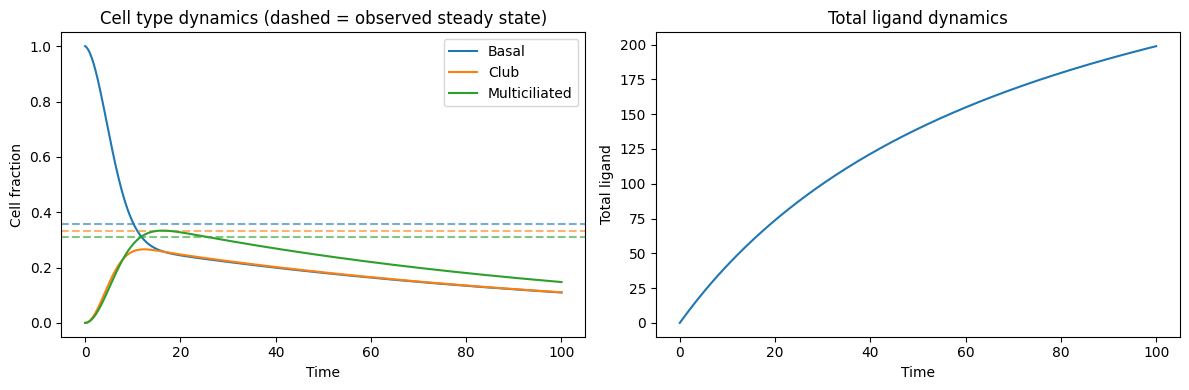

In [70]:
from scipy.integrate import solve_ivp

# Parameters
m = 0.01  # mortality/turnover rate (equal for all phenotypes)
r = 0.01  # ligand dissociation rate

n_phenotypes = len(phenotypes)
n_ligands = len(ligands)

C = ligand_responsivity.values    # (n_phenotypes, n_ligands): c[nu, alpha]
T = cell_type_transitions.values  # (n_phenotypes, n_phenotypes): T[mu, nu]
P = ligand_production.values      # (n_ligands, n_phenotypes): P[alpha, gamma]
TC = T @ C                        # precompute (n_phenotypes, n_ligands)

rng = np.random.default_rng(seed=42)
# k = rng.binomial(1, 0.1, size=n_ligands)  # fixed random external supply rate per ligand
k = supplied_ligands[0]*0.1

def dydt(t, y):
    N = y[:n_phenotypes]
    L = y[n_phenotypes:]

    CL = C @ L  # effective signal per phenotype, shape (n_phenotypes,)

    # dN_mu/dt = sum_{nu,alpha} T_{mu,nu} c_{nu,alpha} L_alpha N_nu
    #           - sum_{gamma,beta} T_{gamma,mu} c_{mu,beta} L_beta N_mu
    #           - m * N_mu
    gain_N = T @ (N * CL)
    loss_N = N * CL * T.sum(axis=0)
    dN = gain_N - loss_N - m * N

    # dL_alpha/dt = k_alpha - r L_alpha
    #              - L_alpha * sum_{mu,nu} T_{mu,nu} c_{nu,alpha} N_mu
    #              + sum_gamma P_{gamma,alpha} N_gamma
    consumption_L = L * (TC.T @ N)
    production_L = P @ N
    dL = k - r * L - consumption_L + production_L

    return np.concatenate([dN, dL])

# Initial conditions: only basal cells, no ligands
N0 = np.array([1, 0, 0])
L0 = np.zeros(n_ligands)
y0 = np.concatenate([N0, L0])

t_span = (0, 100)
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(dydt, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-6)
print(f'Integration {"succeeded" if sol.success else "failed"}: {sol.message}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Observed steady-state fractions from control data (normalized to phenotypes of interest)
observed_counts = control_data.obs['cell_states'].value_counts()
observed_counts = observed_counts[phenotypes]
observed_fractions = observed_counts / observed_counts.sum()

N_sol = sol.y[:n_phenotypes]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, ptype in enumerate(phenotypes):
    axes[0].plot(sol.t, N_sol[i], label=ptype, color=colors[i])
    axes[0].axhline(observed_fractions[ptype], color=colors[i], linestyle='--', alpha=0.6)

axes[0].set_xlabel('Time')
axes[0].set_ylabel('Cell fraction')
axes[0].set_title('Cell type dynamics (dashed = observed steady state)')
axes[0].legend()

L_sol = sol.y[n_phenotypes:]
axes[1].plot(sol.t, L_sol.sum(axis=0))
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Total ligand')
axes[1].set_title('Total ligand dynamics')

plt.tight_layout()
plt.show()
